<a href="https://www.kaggle.com/code/lalit7881/airport-traffic-dataset-2025-eda?scriptVersionId=312976575" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nilesh2042/airport-traffic-dataset/airport_traffic_2025.csv
/kaggle/input/datasets/nilesh2042/airport-traffic-dataset/airport_traffic_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nilesh2042/airport-traffic-dataset/airport_traffic_2025.csv")

In [3]:
df.head()

,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
0,2025,1,JAN,2025-01-01,LATI,Tirana,Albania,64,62,126,NaN,NaN,NaN
1,2025,1,JAN,2025-01-01,UDYZ,Yerevan,Armenia,57,54,111,NaN,NaN,NaN
2,2025,1,JAN,2025-01-01,LOWG,Graz,Austria,7,6,13,NaN,NaN,NaN
3,2025,1,JAN,2025-01-01,LOWI,Innsbruck,Austria,24,25,49,NaN,NaN,NaN
4,2025,1,JAN,2025-01-01,LOWK,Klagenfurt,Austria,2,0,2,NaN,NaN,NaN


In [4]:
df.tail()

,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
116015,2025,12,DEC,2025-12-31,EGNX,East Midlands,United Kingdom,52,59,111,NaN,NaN,NaN
116016,2025,12,DEC,2025-12-31,EGPD,Aberdeen,United Kingdom,35,33,68,NaN,NaN,NaN
116017,2025,12,DEC,2025-12-31,EGPF,Glasgow,United Kingdom,72,73,145,NaN,NaN,NaN
116018,2025,12,DEC,2025-12-31,EGPH,Edinburgh,United Kingdom,137,137,274,137.0,137.0,274.0
116019,2025,12,DEC,2025-12-31,EGSS,London - Stansted,United Kingdom,221,221,442,219.0,221.0,440.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116020 entries, 0 to 116019
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   YEAR           116020 non-null  int64  
 1   MONTH_NUM      116020 non-null  int64  
 2   MONTH_MON      116020 non-null  object 
 3   FLT_DATE       116020 non-null  object 
 4   APT_ICAO       116020 non-null  object 
 5   APT_NAME       116020 non-null  object 
 6   STATE_NAME     116020 non-null  object 
 7   FLT_DEP_1      116020 non-null  int64  
 8   FLT_ARR_1      116020 non-null  int64  
 9   FLT_TOT_1      116020 non-null  int64  
 10  FLT_DEP_IFR_2  34128 non-null   float64
 11  FLT_ARR_IFR_2  34128 non-null   float64
 12  FLT_TOT_IFR_2  34128 non-null   float64
dtypes: float64(3), int64(5), object(5)
memory usage: 11.5+ MB


In [6]:
df.isnull().sum()

YEAR                 0
MONTH_NUM            0
MONTH_MON            0
FLT_DATE             0
APT_ICAO             0
APT_NAME             0
STATE_NAME           0
FLT_DEP_1            0
FLT_ARR_1            0
FLT_TOT_1            0
FLT_DEP_IFR_2    81892
FLT_ARR_IFR_2    81892
FLT_TOT_IFR_2    81892
dtype: int64

In [7]:
df.describe()

,YEAR,MONTH_NUM,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
count,116020.0,116020.000000,116020.000000,116020.000000,116020.000000,34128.000000,34128.000000,34128.000000
mean,2025.0,6.542501,74.043449,74.104404,148.147854,192.939932,192.635314,385.575246
std,0.0,3.438264,125.074164,125.075325,250.123017,168.015658,167.919950,335.881007
min,2025.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2025.0,4.000000,6.000000,6.000000,12.000000,80.000000,79.000000,159.000000
50%,2025.0,7.000000,20.000000,20.000000,39.000000,132.000000,132.000000,263.000000
75%,2025.0,10.000000,87.000000,87.000000,174.000000,265.000000,265.000000,531.000000
max,2025.0,12.000000,846.000000,844.000000,1688.000000,852.000000,850.000000,1696.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

YEAR               int64
MONTH_NUM          int64
MONTH_MON         object
FLT_DATE          object
APT_ICAO          object
APT_NAME          object
STATE_NAME        object
FLT_DEP_1          int64
FLT_ARR_1          int64
FLT_TOT_1          int64
FLT_DEP_IFR_2    float64
FLT_ARR_IFR_2    float64
FLT_TOT_IFR_2    float64
dtype: object

In [10]:
df.shape

(116020, 13)

In [11]:
df.columns

Index(['YEAR', 'MONTH_NUM', 'MONTH_MON', 'FLT_DATE', 'APT_ICAO', 'APT_NAME',
       'STATE_NAME', 'FLT_DEP_1', 'FLT_ARR_1', 'FLT_TOT_1', 'FLT_DEP_IFR_2',
       'FLT_ARR_IFR_2', 'FLT_TOT_IFR_2'],
      dtype='object')

In [12]:
df.nunique()

YEAR                1
MONTH_NUM          12
MONTH_MON          12
FLT_DATE          365
APT_ICAO          331
APT_NAME          331
STATE_NAME         42
FLT_DEP_1         830
FLT_ARR_1         828
FLT_TOT_1        1597
FLT_DEP_IFR_2     836
FLT_ARR_IFR_2     834
FLT_TOT_IFR_2    1624
dtype: int64

## EDA

   YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO    APT_NAME STATE_NAME  \
0  2025          1       JAN  2025-01-01     LATI      Tirana    Albania   
1  2025          1       JAN  2025-01-01     UDYZ     Yerevan    Armenia   
2  2025          1       JAN  2025-01-01     LOWG        Graz    Austria   
3  2025          1       JAN  2025-01-01     LOWI   Innsbruck    Austria   
4  2025          1       JAN  2025-01-01     LOWK  Klagenfurt    Austria   

   FLT_DEP_1  FLT_ARR_1  FLT_TOT_1  FLT_DEP_IFR_2  FLT_ARR_IFR_2  \
0         64         62        126            NaN            NaN   
1         57         54        111            NaN            NaN   
2          7          6         13            NaN            NaN   
3         24         25         49            NaN            NaN   
4          2          0          2            NaN            NaN   

   FLT_TOT_IFR_2  
0            NaN  
1            NaN  
2            NaN  
3            NaN  
4            NaN  
<class 'pandas.core.

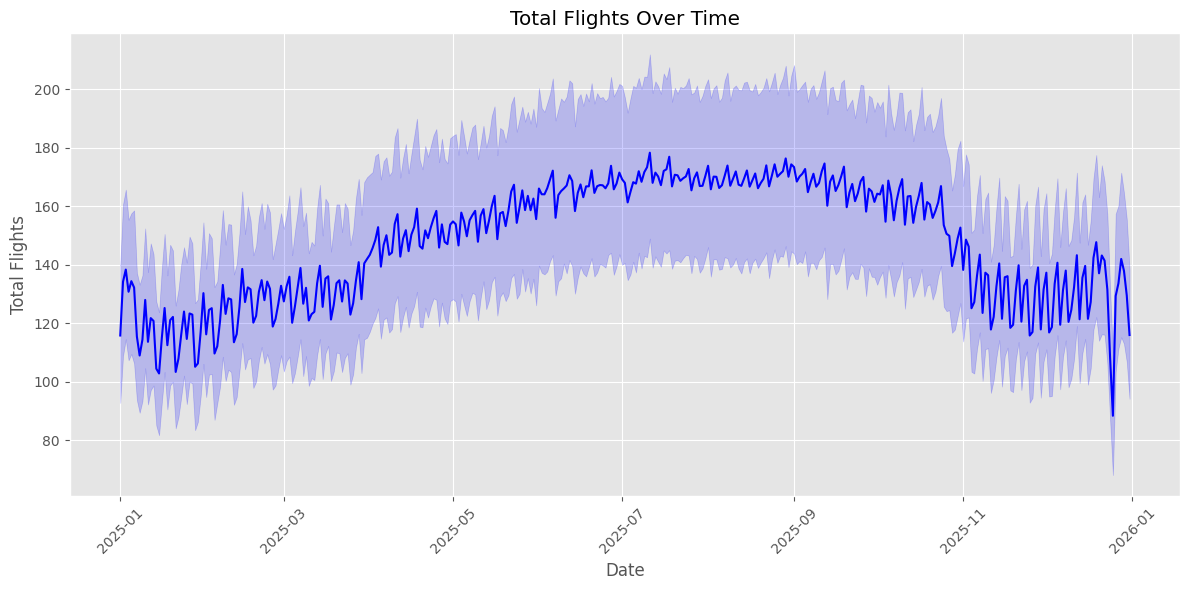

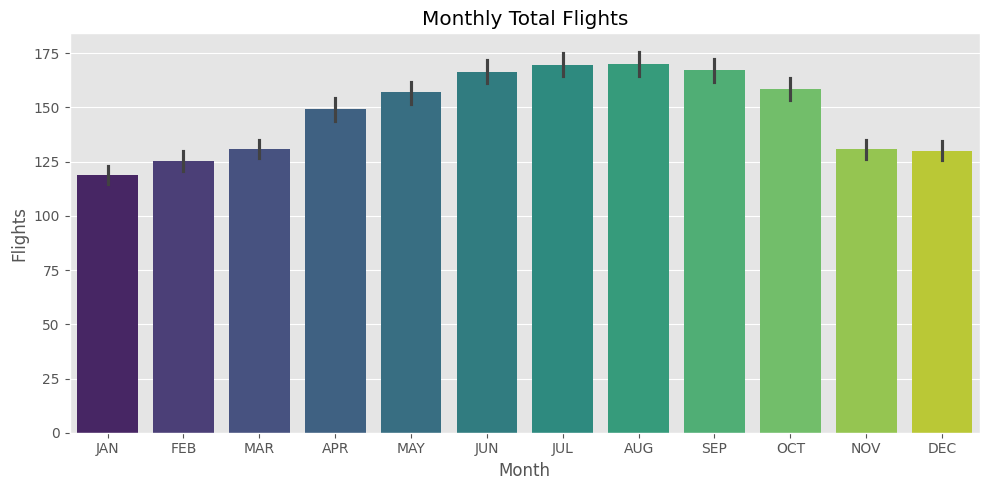

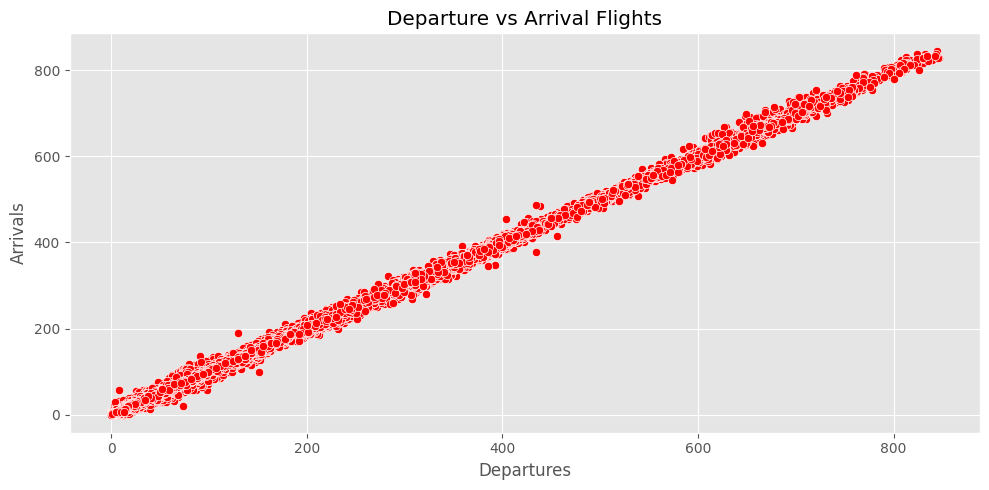

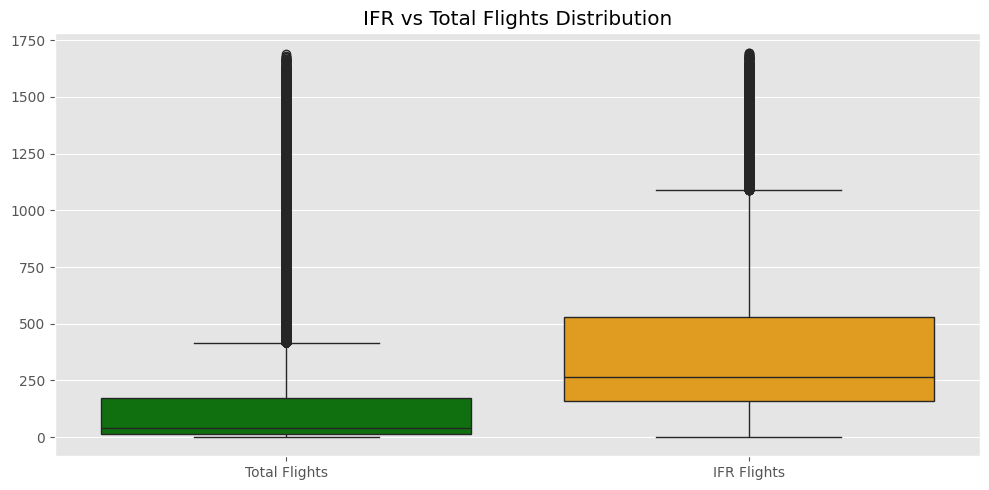

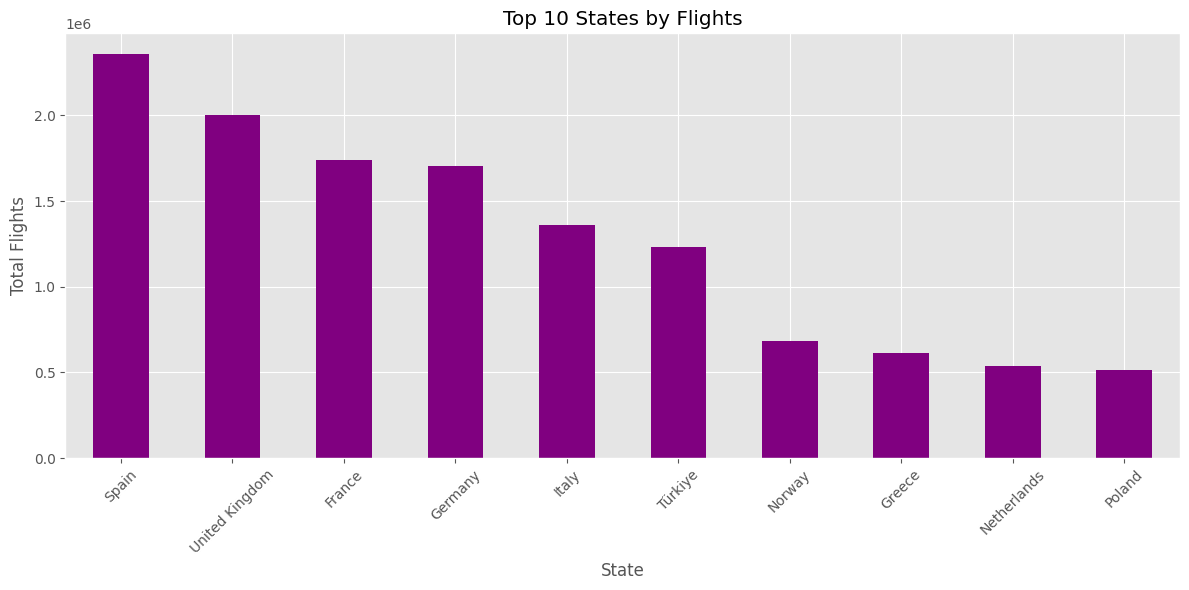

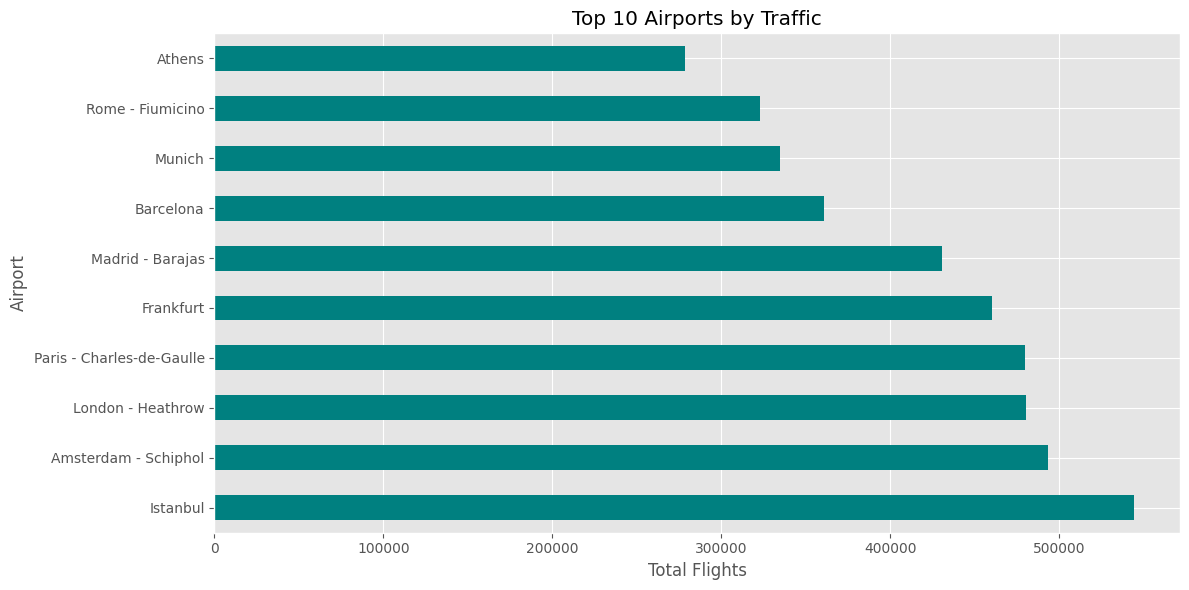

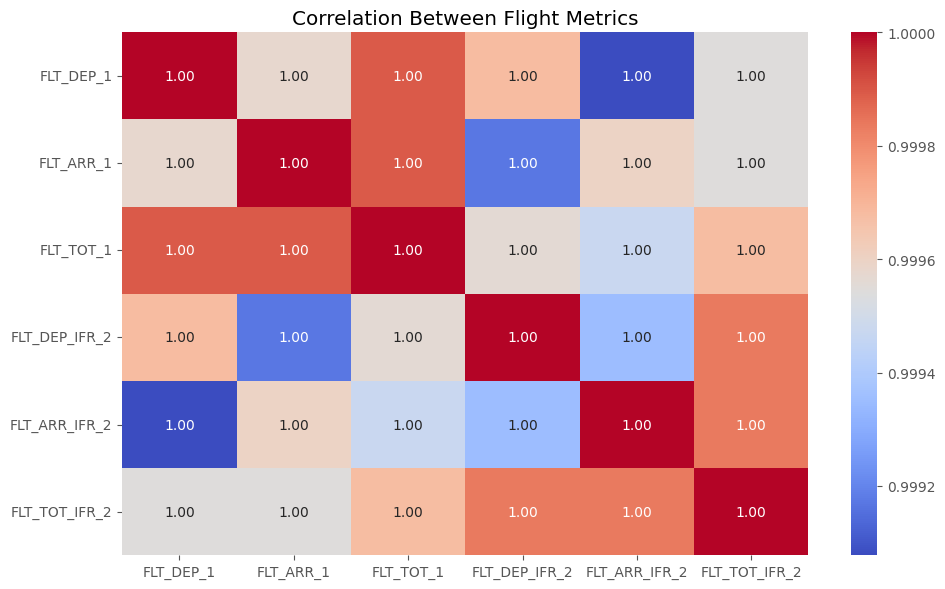

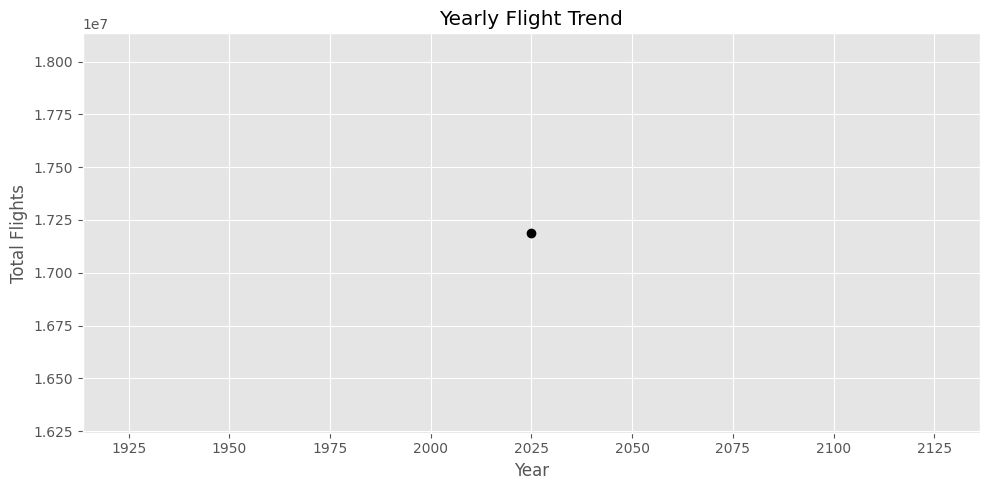

In [13]:
# Style
plt.style.use('ggplot')
# ==============================
# BASIC INFO
# ==============================
print(df.head())
print(df.info())

# Convert date column
df['FLT_DATE'] = pd.to_datetime(df['FLT_DATE'], errors='coerce')

# ==============================
# 1. TOTAL FLIGHTS OVER TIME
# ==============================
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='FLT_DATE', y='FLT_TOT_1', color='blue')
plt.title('Total Flights Over Time')
plt.xlabel('Date')
plt.ylabel('Total Flights')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================
# 2. MONTHLY FLIGHT DISTRIBUTION
# ==============================
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='MONTH_MON', y='FLT_TOT_1', palette='viridis')
plt.title('Monthly Total Flights')
plt.xlabel('Month')
plt.ylabel('Flights')
plt.tight_layout()
plt.show()

# ==============================
# 3. DEPARTURE vs ARRIVAL
# ==============================
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=df,
    x='FLT_DEP_1',
    y='FLT_ARR_1',
    color='red'
)
plt.title('Departure vs Arrival Flights')
plt.xlabel('Departures')
plt.ylabel('Arrivals')
plt.tight_layout()
plt.show()

# ==============================
# 4. IFR vs NON-IFR FLIGHTS
# ==============================
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['FLT_TOT_1', 'FLT_TOT_IFR_2']], palette=['green', 'orange'])
plt.title('IFR vs Total Flights Distribution')
plt.xticks([0,1], ['Total Flights', 'IFR Flights'])
plt.tight_layout()
plt.show()

# ==============================
# 5. STATE-WISE FLIGHTS
# ==============================
state_data = df.groupby('STATE_NAME')['FLT_TOT_1'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
state_data.plot(kind='bar', color='purple')
plt.title('Top 10 States by Flights')
plt.xlabel('State')
plt.ylabel('Total Flights')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================
# 6. AIRPORT TRAFFIC (TOP 10)
# ==============================
airport_data = df.groupby('APT_NAME')['FLT_TOT_1'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
airport_data.plot(kind='barh', color='teal')
plt.title('Top 10 Airports by Traffic')
plt.xlabel('Total Flights')
plt.ylabel('Airport')
plt.tight_layout()
plt.show()

# ==============================
# 7. CORRELATION HEATMAP
# ==============================
plt.figure(figsize=(10,6))
corr = df[['FLT_DEP_1','FLT_ARR_1','FLT_TOT_1','FLT_DEP_IFR_2','FLT_ARR_IFR_2','FLT_TOT_IFR_2']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Flight Metrics')
plt.tight_layout()
plt.show()

# ==============================
# 8. YEARLY TREND
# ==============================
yearly = df.groupby('YEAR')['FLT_TOT_1'].sum()

plt.figure(figsize=(10,5))
yearly.plot(kind='line', marker='o', color='black')
plt.title('Yearly Flight Trend')
plt.xlabel('Year')
plt.ylabel('Total Flights')
plt.grid(True)
plt.tight_layout()
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 0.9953120421916203
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3414
           1       1.00      1.00      1.00      3412

    accuracy                           1.00      6826
   macro avg       1.00      1.00      1.00      6826
weighted avg       1.00      1.00      1.00      6826


Decision Tree
Accuracy: 0.9995605039554644
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3414
           1       1.00      1.00      1.00      3412

    accuracy                           1.00      6826
   macro avg       1.00      1.00      1.00      6826
weighted avg       1.00      1.00      1.00      6826


Random Forest
Accuracy: 0.9989745092294169
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3414
           1       1.00      1.00      1.00      3412

    accuracy                           1.00 

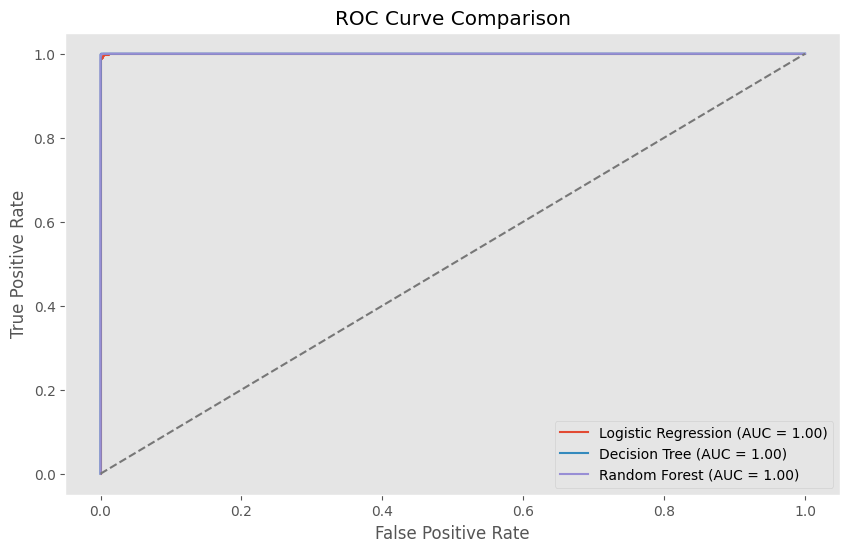

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
# ==============================
# DATA PREPROCESSING
# ==============================

# Convert date
df['FLT_DATE'] = pd.to_datetime(df['FLT_DATE'], errors='coerce')

# Drop missing values (simple handling)
df = df.dropna()

# ==============================
# TARGET CREATION
# ==============================
# Binary classification: High traffic (1) / Low traffic (0)
threshold = df['FLT_TOT_1'].median()

df['TARGET'] = (df['FLT_TOT_1'] > threshold).astype(int)

# ==============================
# FEATURE SELECTION
# ==============================
X = df.drop(columns=['TARGET', 'FLT_TOT_1'])  # avoid leakage
y = df['TARGET']

# ==============================
# TRAIN TEST SPLIT (BEFORE ENCODING ✅)
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# COLUMN TYPES
# ==============================
categorical_cols = ['MONTH_MON', 'APT_ICAO', 'APT_NAME', 'STATE_NAME']
numerical_cols = [
    'YEAR', 'MONTH_NUM', 
    'FLT_DEP_1', 'FLT_ARR_1',
    'FLT_DEP_IFR_2', 'FLT_ARR_IFR_2', 'FLT_TOT_IFR_2'
]

# ==============================
# PREPROCESSING PIPELINE (NO LEAKAGE ✅)
# ==============================
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# ==============================
# MODELS
# ==============================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

# ==============================
# TRAIN + EVALUATE
# ==============================
plt.figure(figsize=(10,6))

for name, model in models.items():
    
    # Pipeline = Preprocessing + Model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# ==============================
# FINAL ROC CURVE
# ==============================
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()
plt.show()

## Thank you..pls upvote!!!!!!